# Footfall: Data Cleaning, Exploratory Data Analysis and Distribution

In [1]:
pip install matplotlib geopandas numpy scipy folium plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

The datasets for Bradford District, BID, Bradford City Centre and Lister Park are loaded, concatenated and cleaned.

In [3]:
#Load footfall data for the 'Bradford BID' area
footfall_BID = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\Bradford BID\footfall_all_intervals_all_days_20190101_20260107.csv")
footfall_BID.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6034 entries, 0 to 6033
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area                     6034 non-null   object 
 1   Interval                 6034 non-null   object 
 2   Date                     6034 non-null   object 
 3   Total Footfall           6034 non-null   float64
 4   Average Footfall         6034 non-null   float64
 5   Total Visiting           6034 non-null   float64
 6   Average Visiting         6034 non-null   float64
 7   Total Passing through    6034 non-null   float64
 8   Average Passing through  6034 non-null   float64
dtypes: float64(6), object(3)
memory usage: 424.4+ KB


In [4]:
footfall_BID.head(20)

,area,Interval,Date,Total Footfall,Average Footfall,Total Visiting,Average Visiting,Total Passing through,Average Passing through
0,Bradford,dayOfWeek,Monday,7611940.75,20854.63,2.239247e+06,6134.923092,5.372694e+06,14719.706908
1,Bradford,dayOfWeek,Tuesday,7943595.12,21763.27,2.336812e+06,6402.222800,5.606783e+06,15361.047200
2,Bradford,dayOfWeek,Wednesday,7526345.95,20620.13,2.214067e+06,6065.938916,5.312279e+06,14554.191084
3,Bradford,dayOfWeek,Thursday,7838003.12,21473.98,2.305749e+06,6317.120744,5.532254e+06,15156.859256
4,Bradford,dayOfWeek,Friday,7703468.81,21105.39,2.266172e+06,6208.690563,5.437296e+06,14896.699437
5,Bradford,dayOfWeek,Saturday,6673147.25,18282.60,1.963077e+06,5378.294648,4.710070e+06,12904.305352
6,Bradford,dayOfWeek,Sunday,7290769.68,19974.71,2.144766e+06,5876.072106,5.146003e+06,14098.637894
7,Bradford BID,dayOfWeek,Monday,55773754.18,152804.81,4.350894e+07,119202.569411,1.226482e+07,33602.240589
8,Bradford BID,dayOfWeek,Tuesday,55580348.41,152274.93,4.335806e+07,118789.211628,1.222229e+07,33485.718372
9,Bradford BID,dayOfWeek,Wednesday,54804961.48,150150.58,4.275318e+07,117132.012628,1.205178e+07,33018.567372


In [5]:
footfall_BID['area'].unique()

array(['Bradford', 'Bradford BID'], dtype=object)

In [6]:
#Only the rows describing the Bradford BID area are kept
footfall_BID = footfall_BID[footfall_BID['area'] == 'Bradford BID']
#Only the rows with actual dates/daily data are kept, rows describing DayOfWeek stats are removed
footfall_BID = footfall_BID[footfall_BID['Interval'] == 'daily']

In [7]:
#Load footfall data for the 'Bradford City Centre' area
footfall_CC = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\Bradford City Centre\footfall_all_intervals_all_days_20190101_20260107.csv")
footfall_CC.head(20)

,area,Interval,Date,Total Footfall,Average Footfall,Total Visiting,Average Visiting,Total Passing through,Average Passing through
0,Bradford - City Centre,dayOfWeek,Monday,28306231.41,77551.32,2.212436e+07,60614.676703,6.181875e+06,16936.643297
1,Bradford - City Centre,dayOfWeek,Tuesday,29196912.19,79991.54,2.282052e+07,62521.970433,6.376393e+06,17469.569567
2,Bradford - City Centre,dayOfWeek,Wednesday,29238989.02,80106.82,2.285341e+07,62612.074121,6.385582e+06,17494.745879
3,Bradford - City Centre,dayOfWeek,Thursday,29373654.04,80475.76,2.295866e+07,62900.440313,6.414992e+06,17575.319687
4,Bradford - City Centre,dayOfWeek,Friday,29489073.89,80791.98,2.304887e+07,63147.600168,6.440199e+06,17644.379832
5,Bradford - City Centre,dayOfWeek,Saturday,28567630.44,78267.48,2.232867e+07,61174.432576,6.238962e+06,17093.047424
6,Bradford - City Centre,dayOfWeek,Sunday,20996975.78,57525.96,1.641139e+07,44962.709435,4.585587e+06,12563.250565
7,Bradford - City Centre,daily,2019-01-01,63656.86,63656.86,4.957246e+04,49572.462804,1.408440e+04,14084.397196
8,Bradford - City Centre,daily,2019-01-02,133008.44,133008.44,1.035797e+05,103579.660457,2.942878e+04,29428.779543
9,Bradford - City Centre,daily,2019-01-03,70403.68,70403.68,5.482652e+04,54826.515290,1.557716e+04,15577.164710


In [8]:
footfall_CC['area'].unique()

array(['Bradford - City Centre'], dtype=object)

In [9]:
#Only the rows describing the Bradford City Centre area are kept
footfall_CC = footfall_CC[footfall_CC['area'] == 'Bradford - City Centre']
#Only the rows with actual dates/daily data are kept, rows describing DayOfWeek stats are removed
footfall_CC = footfall_CC[footfall_CC['Interval'] == 'daily']
footfall_CC.head()

,area,Interval,Date,Total Footfall,Average Footfall,Total Visiting,Average Visiting,Total Passing through,Average Passing through
7,Bradford - City Centre,daily,2019-01-01,63656.86,63656.86,49572.462804,49572.462804,14084.397196,14084.397196
8,Bradford - City Centre,daily,2019-01-02,133008.44,133008.44,103579.660457,103579.660457,29428.779543,29428.779543
9,Bradford - City Centre,daily,2019-01-03,70403.68,70403.68,54826.515290,54826.515290,15577.164710,15577.164710
10,Bradford - City Centre,daily,2019-01-04,62432.69,62432.69,48619.146512,48619.146512,13813.543488,13813.543488
11,Bradford - City Centre,daily,2019-01-05,124109.52,124109.52,98241.638012,98241.638012,25867.881988,25867.881988


In [10]:
#Load footfall data for the 'Lister Park' area
footfall_Lister = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\Lister Park\footfall_all_intervals_all_days_20190101_20260107.csv")
footfall_Lister.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3017 entries, 0 to 3016
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area                     3017 non-null   object 
 1   Interval                 3017 non-null   object 
 2   Date                     3017 non-null   object 
 3   Total Footfall           3017 non-null   float64
 4   Average Footfall         3017 non-null   float64
 5   Total Visiting           3017 non-null   float64
 6   Average Visiting         3017 non-null   float64
 7   Total Passing through    3017 non-null   float64
 8   Average Passing through  3017 non-null   float64
dtypes: float64(6), object(3)
memory usage: 212.3+ KB


In [11]:
footfall_Lister['area'].unique()

array(['Bradford'], dtype=object)

In [12]:
#Rename the area column to make it clear it is 'Lister Park'
footfall_Lister['area'] = 'Lister Park'
footfall_Lister['area'].unique()

array(['Lister Park'], dtype=object)

In [13]:
#Only the rows with actual dates/daily data are kept, rows describing DayOfWeek stats are removed
footfall_Lister = footfall_Lister[footfall_Lister['Interval'] == 'daily']

In [14]:
#Concatenate the 3 datasets together (have the same columns)
footfall_mix = pd.concat([footfall_BID, footfall_CC, footfall_Lister], axis=0)
#Reset index
footfall_mix = footfall_mix.reset_index(drop= True)
#Check, should now have 7683 rows of data
footfall_mix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7683 entries, 0 to 7682
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area                     7683 non-null   object 
 1   Interval                 7683 non-null   object 
 2   Date                     7683 non-null   object 
 3   Total Footfall           7683 non-null   float64
 4   Average Footfall         7683 non-null   float64
 5   Total Visiting           7683 non-null   float64
 6   Average Visiting         7683 non-null   float64
 7   Total Passing through    7683 non-null   float64
 8   Average Passing through  7683 non-null   float64
dtypes: float64(6), object(3)
memory usage: 540.3+ KB


In [15]:
# In the analysis only the total daily 'Total Footfall' variable will be used
# Drop columns not used in analysis
footfall_mix = footfall_mix.drop(columns=['Interval', 
                                          'Average Footfall', 
                                          'Total Visiting', 
                                          'Average Visiting', 
                                          'Total Passing through',
                                          'Average Passing through'])

In [16]:
#Check area names and counts
footfall_mix['area'].value_counts()

area
Bradford BID              2561
Bradford - City Centre    2561
Lister Park               2561
Name: count, dtype: int64

In [17]:
#Rename date and footfall columns
footfall_mix = footfall_mix.rename(columns={'Date':'datestamp'})
footfall_mix = footfall_mix.rename(columns={'Total Footfall':'estimated_actual_footfall'})

In [18]:
#Load footfall data for the 'Bradford MetOffice' aka district area
footfall_Met = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\footfall-MetOffice.csv")
footfall_Met.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          2470 non-null   object 
 1   centre_name                        2470 non-null   object 
 2   purchasing_power_quantile          2470 non-null   int64  
 3   estimated_actual_footfall          2306 non-null   float64
 4   estimated_actual_footfall_rolling  2470 non-null   int64  
 5   indexed_signal                     0 non-null      float64
 6   indexed_signal_rolling             0 non-null      float64
 7   source                             2470 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 154.5+ KB


In [19]:
#Prepare the footfall for Bradford MetOffice area
footfall_Met = footfall_Met.drop(columns=['purchasing_power_quantile', 'indexed_signal', 'indexed_signal_rolling', 'source'])
footfall_Met = footfall_Met.rename(columns={'centre_name': 'area'})
footfall_Met.head()

,datestamp,area,estimated_actual_footfall,estimated_actual_footfall_rolling
0,2019-01-01,Met Office - Bradford,530996.0,571980
1,2019-01-02,Met Office - Bradford,568621.0,572734
2,2019-01-03,Met Office - Bradford,606939.0,538667
3,2019-01-04,Met Office - Bradford,508695.0,532787
4,2019-01-05,Met Office - Bradford,468546.0,507700


In [20]:
#Add the bradford district footfall (MetOffice)
#Concatenate the now 4 datasets together (have the same columns)
footfall_mix = pd.concat([footfall_mix, footfall_Met], axis=0)
#Reset index
footfall_mix = footfall_mix.reset_index(drop= True)

#Convert datestamp to datetime
footfall_mix['datestamp'] = pd.to_datetime(footfall_mix['datestamp'])
footfall_mix.head()

,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling
0,Bradford BID,2019-01-01,95485.29,NaN
1,Bradford BID,2019-01-02,304504.44,NaN
2,Bradford BID,2019-01-03,108258.89,NaN
3,Bradford BID,2019-01-04,62432.69,NaN
4,Bradford BID,2019-01-05,169199.79,NaN


In [21]:
footfall_mix['area'].value_counts()

area
Bradford BID              2561
Bradford - City Centre    2561
Lister Park               2561
Met Office - Bradford     2470
Name: count, dtype: int64

In [22]:
#Check for 0s
print(footfall_mix.isnull().sum())

area                                    0
datestamp                               0
estimated_actual_footfall             164
estimated_actual_footfall_rolling    7683
dtype: int64


In [23]:
#Check for duplicates
print(footfall_mix.duplicated().sum())

0


In [24]:
#Check missing data in 'estimated_actual_footfall'
footfall_mix['estimated_actual_footfall'].isna().value_counts()

estimated_actual_footfall
False    9989
True      164
Name: count, dtype: int64

In [25]:
#Check basic stats
footfall_mix.describe()

,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling
count,10153,9.989000e+03,2.470000e+03
mean,2022-06-22 22:33:12.002363904,2.146431e+05,6.870067e+05
min,2019-01-01 00:00:00,2.263950e+03,4.774620e+05
25%,2020-09-26 00:00:00,3.634543e+04,5.993600e+05
50%,2022-06-23 00:00:00,1.004051e+05,6.349780e+05
75%,2024-03-18 00:00:00,2.196834e+05,7.239568e+05
max,2026-01-04 00:00:00,1.150276e+06,1.252827e+06
std,NaN,2.541940e+05,1.420378e+05


In [26]:
#Rename dataset so its easier to recycle code from previous notebooks
footfall = footfall_mix.copy()

Different variables columns are created to allow data exploration, extracting from the dates the year, the week of the year, the day of week, the month.

In [27]:
footfall['year']= footfall['datestamp'].dt.year
footfall['month'] = footfall['datestamp'].dt.month
footfall['monthday'] = footfall['datestamp'].dt.day
footfall['weekday'] = footfall['datestamp'].dt.weekday
footfall['week_of_year'] = footfall['datestamp'].dt.isocalendar().week
footfall.head()

,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year
0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1
1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1
2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1
3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1
4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1


For machine learning model, cyclical encoding will be required, thus based on temporal variables previously created the following variables are created:
* day of week (sin and cos)
* day of month (sin and cos)
* week of year (sin and cos)
* month (sin and cos)

In [28]:
#Create function to create sin and cos columns of variables
def add_sin_and_cos_features(df, column_to_transform):
    df['Sin_{}'.format(column_to_transform)] = np.sin(2 * np.pi * df[column_to_transform] / max(df[column_to_transform])) 
    df['Cos_{}'.format(column_to_transform)] = np.cos(2 * np.pi * df[column_to_transform] / max(df[column_to_transform]))
    return df

In [29]:
#Apply function
footfall = add_sin_and_cos_features(footfall, 'weekday')
footfall = add_sin_and_cos_features(footfall, 'monthday')
footfall = add_sin_and_cos_features(footfall, 'week_of_year')
footfall = add_sin_and_cos_features(footfall, 'month')
footfall.head(15)

,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month
0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025
1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025
2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025
3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,-8.660254e-01,-0.5,0.724793,0.688967,0.118273,0.992981,0.5,0.866025
4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,-8.660254e-01,0.5,0.848644,0.528964,0.118273,0.992981,0.5,0.866025
5,Bradford BID,2019-01-06,75844.85,NaN,2019,1,6,6,1,-2.449294e-16,1.0,0.937752,0.347305,0.118273,0.992981,0.5,0.866025
6,Bradford BID,2019-01-07,94789.75,NaN,2019,1,7,0,2,0.000000e+00,1.0,0.988468,0.151428,0.234886,0.972023,0.5,0.866025
7,Bradford BID,2019-01-08,125335.17,NaN,2019,1,8,1,2,8.660254e-01,0.5,0.998717,-0.050649,0.234886,0.972023,0.5,0.866025
8,Bradford BID,2019-01-09,60253.09,NaN,2019,1,9,2,2,8.660254e-01,-0.5,0.968077,-0.250653,0.234886,0.972023,0.5,0.866025
9,Bradford BID,2019-01-10,119977.90,NaN,2019,1,10,3,2,1.224647e-16,-1.0,0.897805,-0.440394,0.234886,0.972023,0.5,0.866025


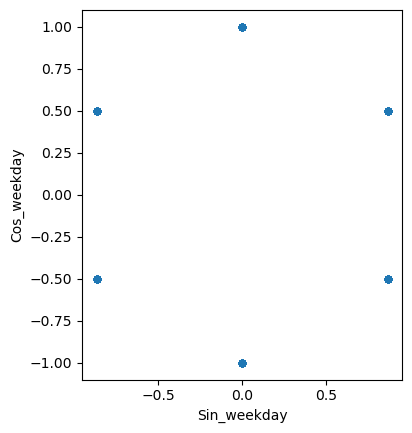

In [30]:
#Check
ax = footfall.plot.scatter('Sin_weekday', 'Cos_weekday').set_aspect('equal')

Finding area centroids from their geometries:

In [31]:
#Load file with different geographical areas of Bradford
GDF_areas = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\areas.geojson")
GDF_areas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   centre_name  8 non-null      object  
 1   geometry     8 non-null      geometry
dtypes: geometry(1), object(1)
memory usage: 260.0+ bytes


In [32]:
#Print CRS
print(GDF_areas.crs)

EPSG:4326


In [33]:
GDF_areas['centre_name'].unique()

array(['Bowling Park - BD4 7', 'Wibsey Park - BD6 3',
       'Cliffe Castle Park - BD20 6', 'Lister Park - BD9 4',
       'Bradford BID', 'Met Office - Bradford', 'Bradford - City Centre',
       'Bradford - Penistone Hill'], dtype=object)

Here for all 4 areas (Bradford MetOf, Bradford BID, City Centre and Lister Park), I isolate their corresponding polygon from the 'GDF_areas' dataset, and find the coordinates of their centroid. This will be used later on in the data scraping notebook to collect weather data.

In [34]:
#Isolate the Bradford MetOffice area
geo_BID = GDF_areas[GDF_areas['centre_name'] == 'Met Office - Bradford']
#Find centroid in projected coordinates
BID_centroid = geo_BID.geometry.centroid
print(BID_centroid)

5    POINT (-1.85473 53.84471)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32232\3313044296.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  BID_centroid = geo_BID.geometry.centroid


In [35]:
#Isolate the Bradford BID area
geo_BID = GDF_areas[GDF_areas['centre_name'] == 'Bradford BID']
#Find centroid in projected coordinates
BID_centroid = geo_BID.geometry.centroid
print(BID_centroid)

4    POINT (-1.75189 53.79375)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32232\3724962223.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  BID_centroid = geo_BID.geometry.centroid


In [36]:
#Isolate the Bradford City Centre area
geo_cc = GDF_areas[GDF_areas['centre_name'] == 'Bradford - City Centre']
#Find centroid in projected coordinates
CC_centroid = geo_cc.geometry.centroid
print(CC_centroid)

6    POINT (-1.75405 53.79221)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32232\4128320459.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  CC_centroid = geo_cc.geometry.centroid


In [37]:
#Isolate the Lister Park area
geo_Lister = GDF_areas[GDF_areas['centre_name'] == 'Lister Park - BD9 4']
#Find centroid in projected coordinates
Lister_centroid = geo_Lister.geometry.centroid
print(Lister_centroid)

3    POINT (-1.77294 53.81292)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32232\1188129232.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  Lister_centroid = geo_Lister.geometry.centroid


## Exploratory Data Analysis

In [38]:
footfall['area'].unique()

array(['Bradford BID', 'Bradford - City Centre', 'Lister Park',
       'Met Office - Bradford'], dtype=object)

<function matplotlib.pyplot.show(close=None, block=None)>

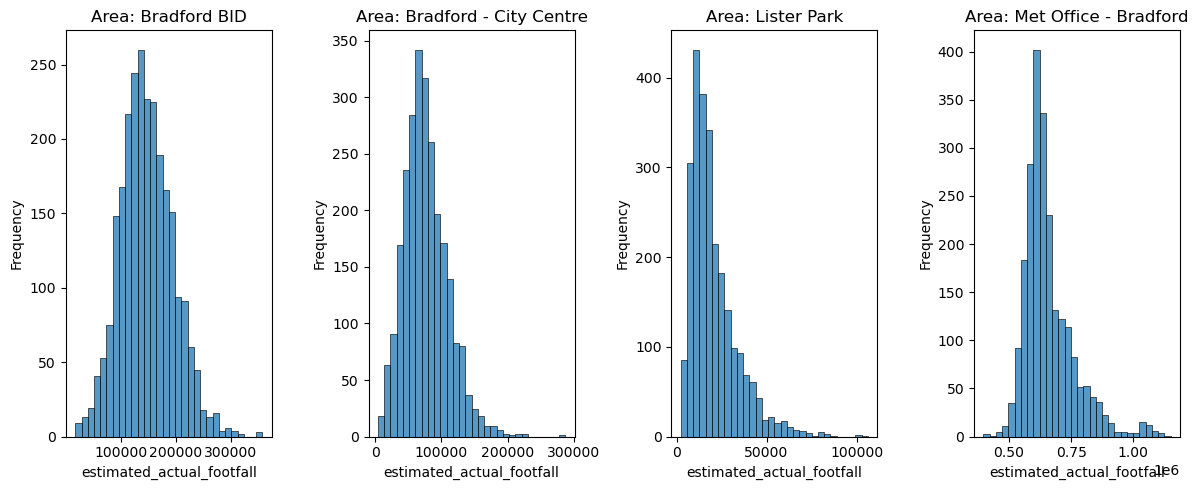

In [39]:
#Plot histograms of footfall counts for the 3 areas

areas = footfall['area'].unique()

fig, axes = plt.subplots(1, 4, figsize=(12, 5))

for ax, area in zip(axes, areas):
    sns.histplot(
        data= footfall[footfall['area']== area],
        x='estimated_actual_footfall',
        bins= 30,
        ax=ax,
    )
    ax.set_title(f'Area: {area}')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show

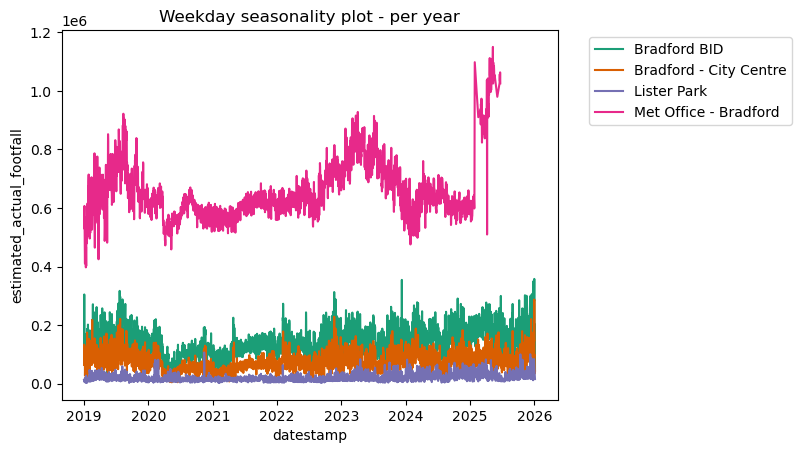

In [40]:
sns.lineplot(data= footfall, 
             x='datestamp', 
             y='estimated_actual_footfall', 
             hue='area', 
             legend='full',
            palette='Dark2')

# add title
plt.title('Weekday seasonality plot - per year')

# move the legend outside of the main figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)

Plot variation over time metrics for the Bradford district area only

In [41]:
timeMetrics = ['weekday','week_of_year', 'month', 'year']
weekday_map= {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

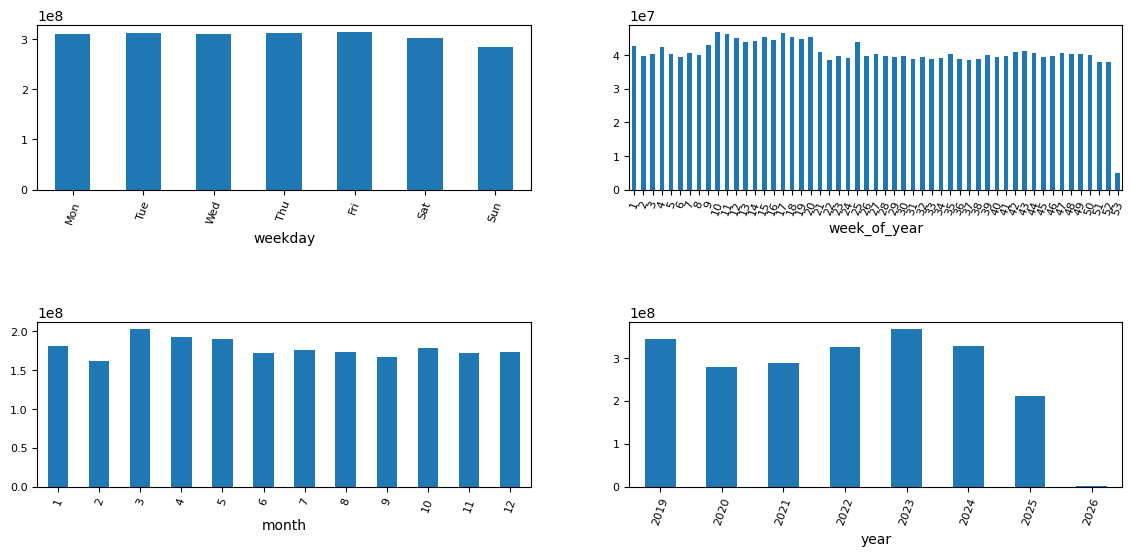

In [42]:
#Create summary plots over weekdays, week of year, months and years

fig, axs = plt.subplots(2, 2, figsize = (14,6))
plt.subplots_adjust(hspace=0.8)    
for i, ax in enumerate(axs.flat):
    metric = timeMetrics[i]
    if metric == 'weekday':
        weekday_series= (
            footfall.groupby(['weekday'])['estimated_actual_footfall']
            .sum()
            .rename(index= weekday_map)
            .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']))
        weekday_series.plot.bar(ax=ax, rot=70, fontsize = 8) 
    else:
        footfall.groupby(metric)['estimated_actual_footfall'].sum().plot.bar(ax=ax, rot=70, fontsize = 8)   

Explore footfall time series (interactive plot which can be re-used in future dashboards)

In [43]:
#Plot interactive line graph of footfall throughout time,
#with button to select area of interest
# with hover option to check exact daily footfall count

import plotly.graph_objects as go

#Isolate regions and 
regions = footfall['area'].unique()

#Create initial figure
fig_BradFF = go.Figure()
buttons = []
trace_count = 0

#Loop through each region
for i, region in enumerate(regions):
    df_region = footfall[footfall['area'] == region].sort_values('datestamp')
    
    #Add traces for this variable
    fig_BradFF.add_scatter(
            x= df_region['datestamp'],
            y= df_region['estimated_actual_footfall'],
            mode='lines',
            name= region,
            line= dict(color='blue', width=2, dash='solid'),
            visible= (i==0), #only first is visible initially
            hovertemplate= '📅 %{x|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}'
    )
    
    trace_count += 1

#Add buttons for dropdown menu
for i, region in enumerate(regions):
    visible_array = [False] * trace_count
    visible_array[i] = True
    buttons.append(dict(
        label=region,
        method='update',
        args=[{'visible': visible_array},
            {'title': f'Footfall Trend - {region}'}]
    ))

#Add dropdown and choose layout
fig_BradFF.update_layout(
    title= f'Footfall Trend - {regions[0]}',
    xaxis = dict(
        title= 'Date',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
        title='Total Footfall',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x= 0.1,
        y=1.2,
        xanchor= 'left',
        yanchor= 'top',
        direction='down',
        showactive= True
    )],
)

fig_BradFF.show()

The previous plot is modified by smoothing the trend line for more clearer visualisation.

In [44]:
#Smooth Spline Curve
#Plot interactive line graph of footfall throughout time
import plotly.express as px
from scipy.interpolate import make_interp_spline
import plotly.graph_objects as go

#Isolate regions
regions = footfall['area'].unique()

#Create initial figure
fig_BradFF = go.Figure()
buttons = []

#Loop through each region
for i, region in enumerate(regions):
    df_region = footfall[footfall['area'] == region].sort_values('datestamp')

    #Data prep
    x = df_region['datestamp']
    y = df_region['estimated_actual_footfall']
    #Remove NaNs
    mask = ~np.isnan(y)
    y = y[mask]
    x = x[mask]

    #Create smoothed line with interpolation
    x_numeric = np.arange(len(x))
    X_Y_Spline = make_interp_spline(x_numeric, y)
    X_ = np.linspace(x_numeric.min(), x_numeric.max(), 500)
    Y_ = X_Y_Spline(X_)

    #Convert the dates back to show timeframe
    x_seconds = np.array([dt.timestamp() for dt in x])
    X_dates_seconds = np.interp(X_, x_numeric, x_seconds)
    X_dates = pd.to_datetime(X_dates_seconds, unit='s')
    
    #Add traces for this variable
    fig_BradFF.add_trace(
        go.Scatter(
            x= X_dates,
            y= Y_,
            mode='lines',
            line= dict(color='blue', width=2, dash='solid'),
            name= region,
            visible= (i==0), #only first is visible initially
            hovertemplate= '📅 %{x|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}')
        )

#Add buttons for dropdown menu
for i, region in enumerate(regions):
    visible_array = [False] * len(regions)
    visible_array[i] = True
    buttons.append(dict(
        label=region,
        method='update',
        args=[{'visible': visible_array},
            {'title': f'Footfall Trend - {region}'}]
    ))

#Add dropdown and choose layout
fig_BradFF.update_layout(
    title= f'Footfall Trend - {regions[0]}',
    xaxis = dict(
        title= 'Date',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
        title='Footfall',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x= 0.1,
        y=1.2,
        xanchor= 'left',
        yanchor= 'top',
        direction='down',
        showactive= True
    )],
)
    
fig_BradFF.show()

Comparing footfall seasonal trends in 2024 VS 2025. The following plots are also made interactive to be reused in dashboards.

In [45]:
# Plot seasonal footfall line graph,
# with months on the x axis
# allowing to compare footfall between 2024 and 2025
# with a button to select the area of interest

import plotly.express as px
import plotly.graph_objects as go

#Isolate the different regions
regions = footfall['area'].unique()

#Create initial empty figure
fig_Brad24vs25 = go.Figure()
buttons = []

#Loop through each region
for r, region in enumerate(regions):
    df_region = footfall[footfall['area'] == region].sort_values('datestamp')

    #Add 2024 and 2025 lines
    for year, color in zip([2024, 2025], ['blue', 'red']):
        df_year = df_region[df_region['datestamp'].dt.year == year].copy()
        if df_year.empty:
            continue

        x_doy = df_year['datestamp'].dt.dayofyear
        y = df_year['estimated_actual_footfall']

        #Add lines
        fig_Brad24vs25.add_scatter(
        x= x_doy,
        y= y,
        mode='lines',
        line= dict(color= color, width=2),
        name= f'{year}',
        visible=(r==0),
        customdata= df_year['datestamp'],
        hovertemplate= '📅 %{customdata|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}'
    )

#Add 1 button per region
visibility = [False] * (2 * len(regions))
visibility[i*2] = True #2024 line
visibility[i*2+1] = True #2025 line

buttons.append(dict(
    label=region,
    method='update',
    args=[{'visible': visibility},
        {'title': f'Footfall Comparison (2024 vs 2025) - {region}'}]
))

#Add buttons for dropdown
for i, region in enumerate(regions):
        visible_array = [False] * (2* len(regions))
        visible_array[2*i] = True #2024 line
        visible_array[2*i +1] = True #2025 line
        buttons.append(dict(
            label= region,
            method='update',
            args=[{'visible': visible_array},
                 {'title': f'Footfall Comparison (2024 vs 2025) - {region}'}]
        ))

#Adapt layout with monthly ticks
month_starts = pd.date_range('2024-01-01', '2024-12-31', freq='MS')
month_labels = month_starts.strftime('%b')


#Add dropdown and choose layout
fig_Brad24vs25.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction= 'down',
        x= 0.01,
        y=1.3,
        xanchor= 'left',
        yanchor= 'top',
        showactive= True
    )],
    hovermode= 'x unified',
    title= f'Footfall Comparison (2024 vs 2025) - {regions[0]}',
    xaxis=dict(
        title= 'Month',
        tickvals=[d.timetuple().tm_yday for d in month_starts],
        ticktext= month_labels,
        range=[1, 366],
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
         title='Footfall',
         showgrid= True,
         gridcolor='lightgrey',
         zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
    
fig_Brad24vs25.show()


Create interactive heatmap - calendar with buttons for years and area of interest.

In [46]:
#Data Preparation

#Create year and weekday column
footfall['year']= footfall['datestamp'].dt.year
footfall['weekday'] = footfall['datestamp'].dt.weekday
#Isolate date string (YYYY-MM-DD)
footfall['date_str'] = footfall['datestamp'].dt.strftime('%Y-%m-%d')
#Create week index to avoid duplicates (change of year can be in same week)
footfall['week_monday'] = footfall['datestamp'] - pd.to_timedelta(footfall['datestamp'].dt.weekday, unit='d')
footfall['week_index'] = footfall['week_monday'].dt.strftime('%Y-%m-%d')

In [47]:
#Set-Up for daily heatmap for each year

#Set up yearly and region filtering
years = sorted(footfall['year'].unique())
regions = sorted(footfall['area'].unique())

#Start with first year and first region to initialize figure
first_year = years[0]
first_region = regions[0]
data_init = footfall[(footfall['year'] == first_year) & (footfall['area'] == first_region)]

#Create pivot table (2D matrix)
pivot = data_init.pivot(index='weekday', 
                        columns='week_index', 
                        values='estimated_actual_footfall')
pivot = pivot.reindex(index=range(7))
#Create other pivot table to have exact dates with hover tool
customdata = data_init.pivot(index='weekday', 
                             columns='week_index', 
                             values='date_str').values

#----------------------------------------------------------------------------------------------

#Create function -> to show month label only at first week of each month
def get_month_ticks(week_index):
    if len(week_index) == 0:
        return [], []
    
    dates= pd.to_datetime(week_index)
    months = dates.month

    #First week of month
    if len(months) == 1:
        first_w_month= np.array([True])
    else:
        first_w_month= np.r_[True, months[1:] != months[:-1]]

    tickvals= week_index[first_w_month]
    ticktext= dates[first_w_month].strftime('%b')

    return tickvals, ticktext

tickvals_init, ticktext_init = get_month_ticks(pivot.columns)

In [48]:
#Plotting daily heatmap

#Create initial heatmap
#Plot Interactive Daily Heatmap
fig_heatmap = px.imshow(
    pivot.values,
    labels= dict(x='Week of Year', y='Day of Week', color='Footfall'),
    x=pivot.columns,
    y=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    color_continuous_scale='viridis_r',
    aspect='auto',
)

#Add hover with daily info
fig_heatmap.update_traces(
    hovertemplate= ' 📅Date:%{customdata}<br> 👣Footfall: %{z:,}',
    customdata= customdata
)

#Apply month ticks
fig_heatmap.update_xaxes(
    tickmode= 'array',
    tickvals= tickvals_init,
    ticktext=ticktext_init
)

#--------------------------------------------------------------------------------------------
#Create dropdown button for YEARS

year_buttons= []

for year in years:
    data_year = footfall[(footfall['year'] == year) & (footfall['area']== first_region)]
    pivot_y = data_year.pivot(index='weekday', 
                              columns='week_index', 
                              values='estimated_actual_footfall').reindex(index=range(7))
    customdata_y = data_year.pivot(index='weekday', 
                                   columns='week_index', 
                                   values='date_str').values
    tickvals_y, ticktext_y = get_month_ticks(pivot_y.columns)

    year_buttons.append(dict(
        label=str(year), #text shown in drop down
        method='update', #update data instead of redrawing
        #z is new heatmap values, customdata is hover data
        args=[{'z': [pivot_y.values], 
               'customdata': [customdata_y], 
               'x':[pivot_y.columns]
               },
               {'xaxis': dict(
                   tickmode= 'array',
                   tickvals= tickvals_y,
                   ticktext= ticktext_y
               ),
              'meta.year': year}]
    ))

#--------------------------------------------------------------------------------------------
#Create dropdown button for REGIONS

region_buttons= []

for region in regions:
    data_region = footfall[(footfall['year'] == first_year) & (footfall['area']== region)]
    pivot_r = data_region.pivot(index='weekday', 
                                columns='week_index', 
                                values='estimated_actual_footfall').reindex(index=range(7))
    customdata_r = data_region.pivot(index='weekday', 
                                     columns='week_index', 
                                     values='date_str').values

    tickvals_r, ticktext_r = get_month_ticks(pivot_r.columns)

    region_buttons.append(dict(
        label= region, #text shown in drop down
        method='update', #update data instead of redrawing
        #z is new heatmap values, customdata is hover data
        args=[{'z': [pivot_r.values], 
               'customdata': [customdata_r],
               'x': [pivot_r.columns]
               },
               {'xaxis': dict(
                   tickmode= 'array',
                   tickvals= tickvals_r,
                   ticktext= ticktext_r
               ),
              'meta.region': region}]
    ))

#--------------------------------------------------------------------------------------------
#Create plot layout
#Add both dropdown menus
fig_heatmap.update_layout(
    meta= dict(year=first_year, region= first_region),
    title= dict(
        text= 'Daily Footfall Heatmap - %{meta.year} - %{meta.region}'
    ),
    updatemenus=[
        dict(buttons= year_buttons, direction='down', x=1, y=1.2, showactive=True, pad={'r':10}),
        dict(buttons= region_buttons, direction='down', x=0.9, y=1.2, showactive=True, pad={'r':10})
    ]
)

#Show plot
fig_heatmap.show()

Compare the percentage footfall counts change between 2024 and 2025 for the 4 different areas:

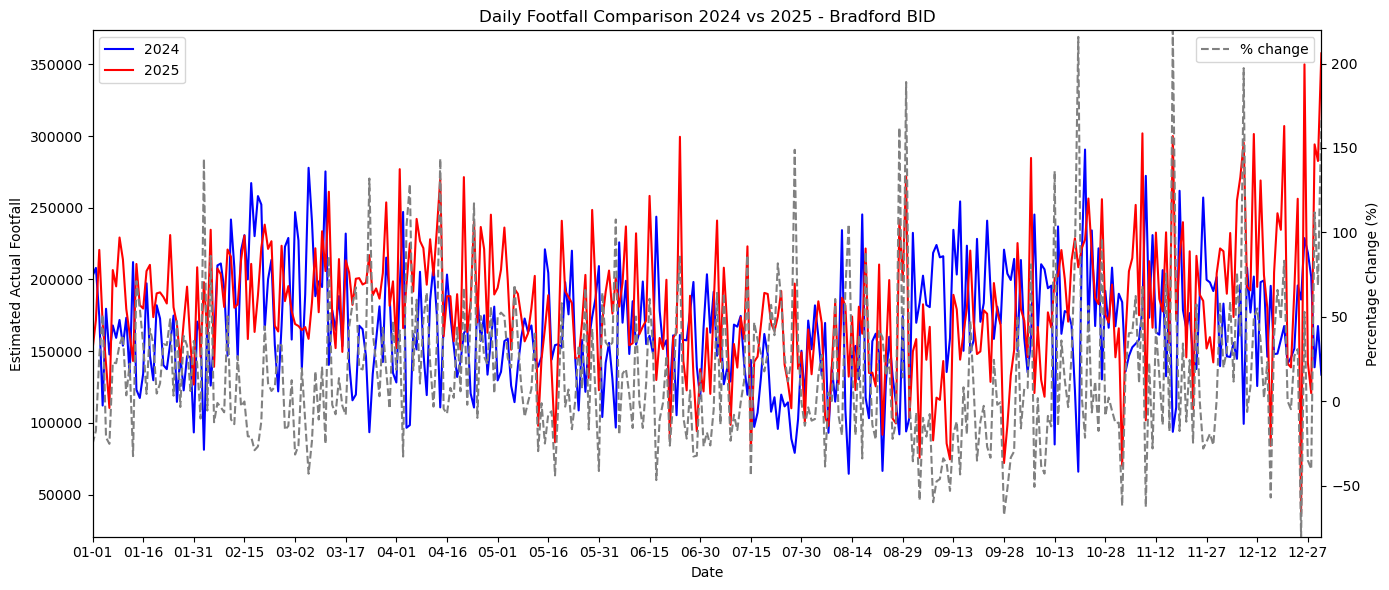


Summary stats for Bradford BID


count    365.000000
mean      16.845782
std       44.799773
min      -80.237076
25%      -12.424330
50%        8.296516
75%       39.043953
max      219.682707
Name: pct_change, dtype: float64

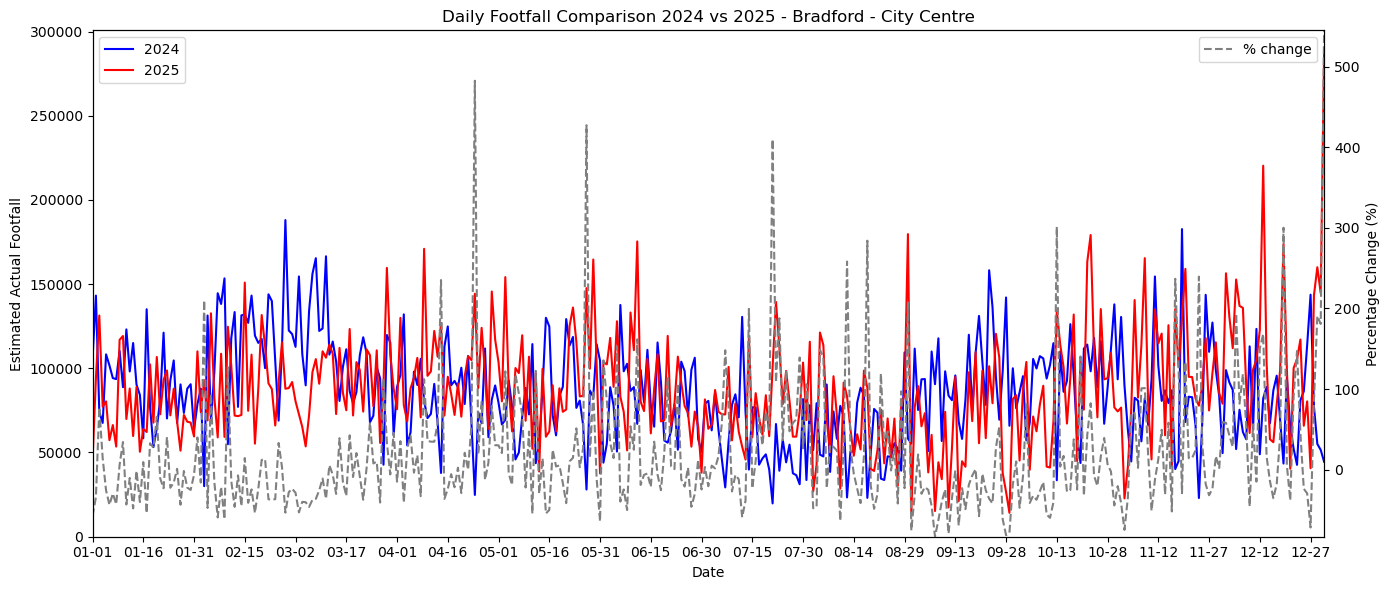


Summary stats for Bradford - City Centre


count    365.000000
mean      20.956958
std       82.098334
min      -83.206966
25%      -29.483916
50%        0.611330
75%       42.120367
max      545.172230
Name: pct_change, dtype: float64

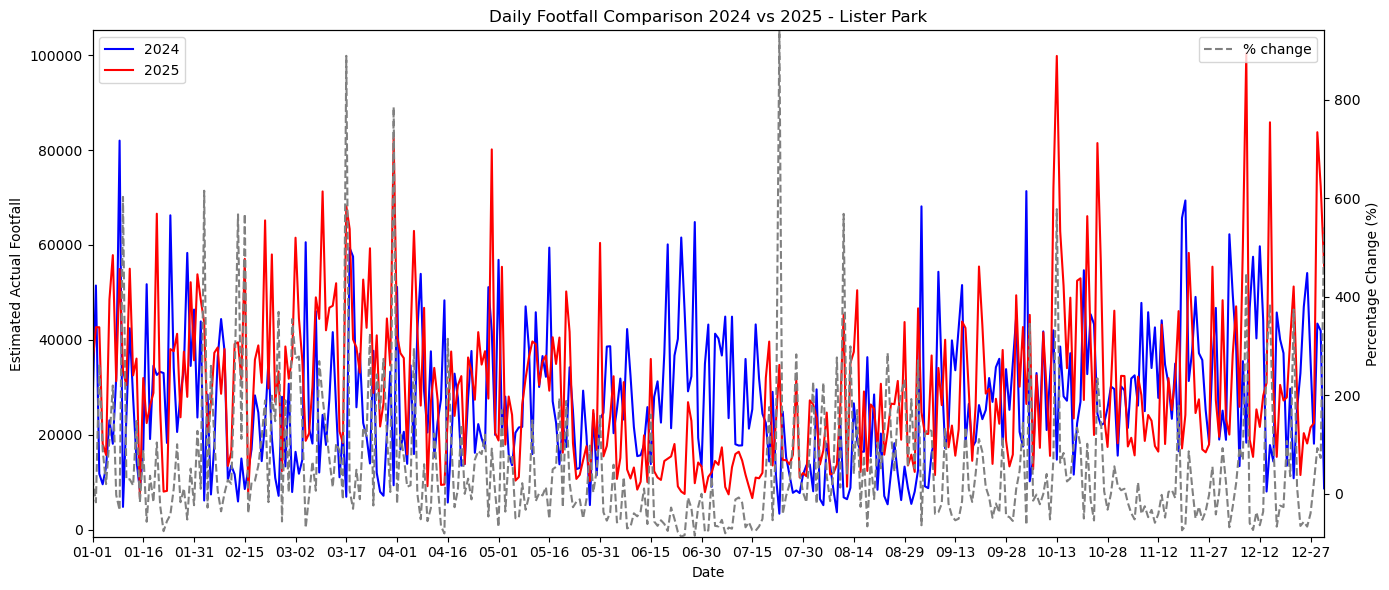


Summary stats for Lister Park


count    365.000000
mean      55.827962
std      145.495926
min      -87.013186
25%      -37.142222
50%       10.272723
75%      102.311424
max      940.895829
Name: pct_change, dtype: float64

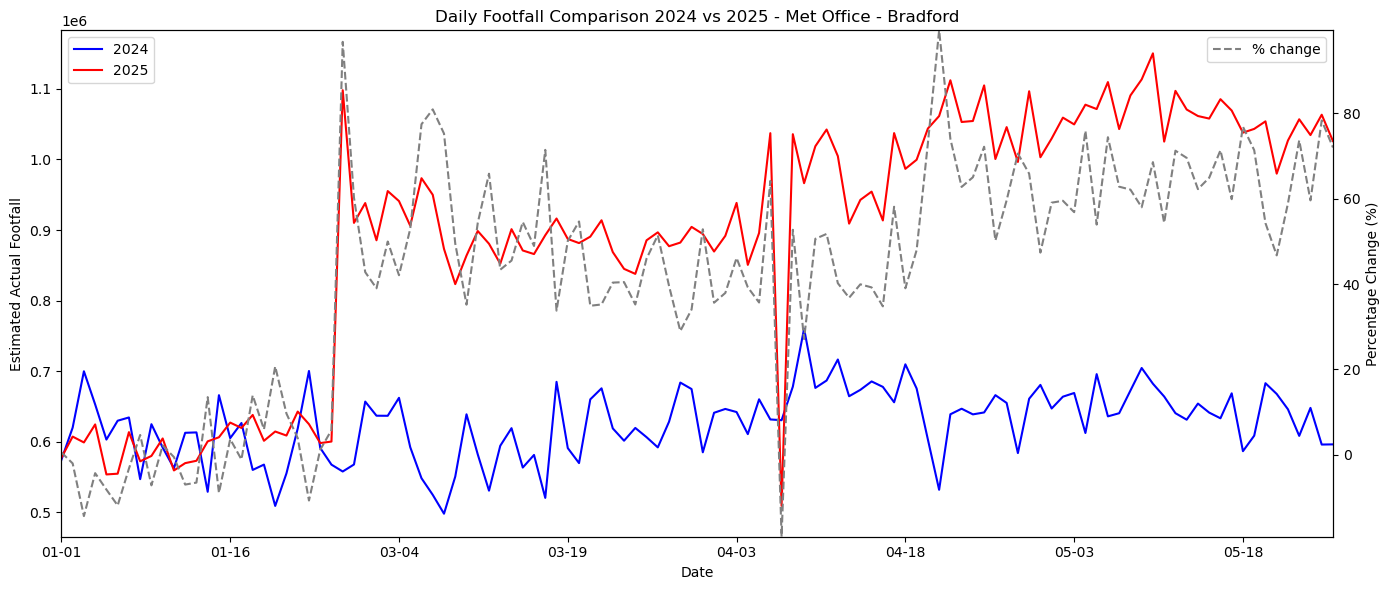


Summary stats for Met Office - Bradford


count    114.000000
mean      42.433200
std       27.481355
min      -19.235349
25%       33.836417
50%       48.437855
75%       62.225521
max       99.480002
Name: pct_change, dtype: float64

In [49]:
#Calculate the percentage change in daily footfall between the 2 years:

#Create a month-day column
footfall['month_day'] = footfall['datestamp'].dt.strftime('%m-%d')
#Keep only the 2024 and 2025 data
footfall_24VS25 = footfall[footfall['year'].isin([2024, 2025])]

regions = footfall_24VS25['area'].unique()

#Loop through regions
for region in regions:
    
    df_r = footfall_24VS25[footfall_24VS25['area'] == region]

    #Create a pivot table per region
    pivot = df_r.pivot(index= 'month_day', columns='year', values='estimated_actual_footfall')
    #Sort the data by month_day
    pivot= pivot.sort_index()
    #Drop days with missing data
    pivot = pivot.dropna(subset=[2024, 2025])
    #Calculate the % change
    pivot['pct_change'] = ((pivot[2025] - pivot[2024]) / pivot[2024]) * 100
    
    #Create a plot for each region
    #Plot line plot of 2024, 2025 and percent change over time
    fig, ax1 = plt.subplots(figsize=(14,6))

    #Plot 2024 and 2025 footfall counts
    ax1.plot(pivot.index, pivot[2024], label='2024', color='blue')
    ax1.plot(pivot.index, pivot[2025], label='2025', color= 'red')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Estimated Actual Footfall')
    ax1.set_xticks(pivot.index[::15]) #have ticks every 15 days
    ax1.legend(loc='upper left')
    ax1.margins(x=0)

    #Plot percentage change between the 2 years
    ax2 = ax1.twinx() #same x axis
    ax2.plot(pivot.index, pivot['pct_change'], label='% change', color= 'grey', linestyle= '--')
    ax2.set_ylabel('Percentage Change (%)')
    ax2.legend(loc='upper right')
    ax2.margins(y=0)

    plt.title(f'Daily Footfall Comparison 2024 vs 2025 - {region}')
    plt.tight_layout()
    plt.show()
    
    #Print stats
    print(f'\nSummary stats for {region}')
    display(pivot['pct_change'].describe())

## Saving the clean data for next steps

In [50]:
footfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10153 entries, 0 to 10152
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   area                               10153 non-null  object        
 1   datestamp                          10153 non-null  datetime64[ns]
 2   estimated_actual_footfall          9989 non-null   float64       
 3   estimated_actual_footfall_rolling  2470 non-null   float64       
 4   year                               10153 non-null  int32         
 5   month                              10153 non-null  int32         
 6   monthday                           10153 non-null  int32         
 7   weekday                            10153 non-null  int32         
 8   week_of_year                       10153 non-null  UInt32        
 9   Sin_weekday                        10153 non-null  float64       
 10  Cos_weekday                       

In [51]:
#Drop columns unneeded for analysis
footfall = footfall.drop(columns=['month_day'])
footfall.head()

,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,date_str,week_monday,week_index
0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,2019-01-01,2018-12-31,2018-12-31
1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,2019-01-02,2018-12-31,2018-12-31
2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025,2019-01-03,2018-12-31,2018-12-31
3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,-8.660254e-01,-0.5,0.724793,0.688967,0.118273,0.992981,0.5,0.866025,2019-01-04,2018-12-31,2018-12-31
4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,-8.660254e-01,0.5,0.848644,0.528964,0.118273,0.992981,0.5,0.866025,2019-01-05,2018-12-31,2018-12-31


In [52]:
#Save the cleaned dataset
footfall.to_csv('footfall_Mix_Clean')